# 04 — Transformer (GPT-2) music generation

**Reconstructed and improved notebook.** The original Transformer notebook was written in Google Colab and was not recoverable. It was rebuilt from:

- Section 2.4.5 of [the project report](../docs/project_report.pdf).
- The Colab screenshots in [`results/figures/transformer/`](../results/figures/transformer/).
- The novelty / diversity / FAD-proxy definitions in the GAN screenshots in [`results/figures/gan/`](../results/figures/gan/).

A first, faithful reproduction used only the first 50 notes of each file. It overfitted after 6 epochs: training accuracy climbed to 0.31 while validation stalled at about 0.12. This version keeps the same model family, metrics and figures, but changes how the data is prepared and how the model is trained:

| | Faithful reproduction | This notebook |
|---|---|---|
| Notes used per file | First 50 only | **Every note**, cut into overlapping 50-note windows |
| Note order | Tracks joined end to end | **Merged by time**, so notes appear in the order they are played |
| Drum channel | Included | **Excluded** (drum hits are not pitches) |
| Augmentation | None | **Random transposition** of each training window by -5 to +6 semitones |
| Train / val split | 80 / 20 by file | 80 / 20 by file (unchanged), so no song appears in both |
| Optimiser | AdamW, fixed LR 1e-3 | AdamW, **warmup + cosine decay**, peak LR 5e-4 |
| Regularisation | Dropout 0.1, weight decay 0.01 | **Dropout 0.2, weight decay 0.1** |
| Stopping | Fixed 15 epochs | **Early stopping** on validation loss, patience 4 |
| Generation prompt | One note | **The real 16-note opening** of a validation song |
| Sampling | Temperature 1.0 | **Temperature 0.9, top-k 10** |

Unchanged: the GPT-2 architecture (4 layers, 4 heads, 256-dim), 50-note sequences, cross-entropy loss, and every metric and figure. Section 7 compares the original report, the faithful reproduction and this version.

Figures are saved to `results/figures/transformer_reproduced/` under the same file names as the originals.

**Running on Google Colab.** Upload this notebook, then choose *Runtime → Change runtime type → T4 GPU*. Run the cells in order. The paths cell will ask you to upload `data/pokemon_midis.zip` from the repo. The last cell downloads every figure, the MIDI file and the metrics as one zip.

**Running locally.** Run `pip install -r requirements.txt`, then open this notebook from the repo's `notebooks/` folder.

## 1. Setup

In [ ]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Colab ships torch, transformers, scikit-learn, scipy, seaborn and pandas; only mido is missing
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mido"], check=True)

In [ ]:
import json
import math
import random
import zipfile
from pathlib import Path

import mido
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Config, GPT2LMHeadModel, get_cosine_schedule_with_warmup
from scipy.spatial.distance import euclidean
from sklearn.metrics import confusion_matrix, mean_squared_error, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cu128 | device: cuda


In [ ]:
# ---- Configuration -------------------------------------------------------
SEED = 42
SEQ_LEN = 50            # report 2.4.5.1: "sequence length = 50" (kept so metrics stay comparable)
TRAIN_SPLIT = 0.8       # report 2.4.5.1: 80 / 20 split, done by file
TRAIN_STRIDE = 10       # a new training window starts every 10 notes
VAL_STRIDE = SEQ_LEN    # validation windows do not overlap
TRANSPOSE_SHIFTS = list(range(-5, 7))   # semitones; training windows only
SKIP_DRUMS = True       # MIDI channel 10 (index 9) is percussion

BATCH_SIZE = 64
MAX_EPOCHS = 30
PATIENCE = 4            # stop after this many epochs without a better validation loss
LR = 5e-4
WARMUP_FRACTION = 0.05
WEIGHT_DECAY = 0.1
N_EMBD, N_LAYER, N_HEAD = 256, 4, 4
DROPOUT = 0.2

PROMPT_LEN = 16         # generation starts from a real 16-note opening
GEN_LEN = 100           # notes generated after the prompt (report 2.4.5.2: ~100 notes)
N_GEN_SAMPLES = 20      # sequences generated for novelty / diversity / FAD
TEMPERATURE = 0.9
TOP_K = 10

CM_EPOCHS = {1, 2}      # validation confusion matrices saved during training; the best model's is saved after

# ---- Paths: locally, find the repo from notebooks/ or the repo root; on Colab, upload the dataset
def find_repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "pokemon_midis.zip").exists():
            return p
    return None


REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    if not IN_COLAB:
        raise FileNotFoundError("data/pokemon_midis.zip not found - run this notebook from inside the repo.")
    from google.colab import files
    REPO_ROOT = Path("/content/symphony-of-algorithms")
    (REPO_ROOT / "data").mkdir(parents=True, exist_ok=True)
    print("Select data/pokemon_midis.zip from the repo:")
    uploaded = files.upload()
    (REPO_ROOT / "data" / "pokemon_midis.zip").write_bytes(next(iter(uploaded.values())))

DATA_ZIP = REPO_ROOT / "data" / "pokemon_midis.zip"
MIDI_DIR = REPO_ROOT / "data" / "Pokemon MIDIs"
FIG_DIR = REPO_ROOT / "results" / "figures" / "transformer_reproduced"
AUDIO_DIR = REPO_ROOT / "results" / "audio"
WEIGHTS_DIR = REPO_ROOT / "Weights"
for d in (FIG_DIR, AUDIO_DIR, WEIGHTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Select data/pokemon_midis.zip from the repo:


Saving pokemon_midis.zip to pokemon_midis.zip


## 2. Load the MIDI corpus

In [ ]:
if not MIDI_DIR.exists():
    with zipfile.ZipFile(DATA_ZIP) as zf:
        zf.extractall(DATA_ZIP.parent)

midi_files = sorted(MIDI_DIR.glob("*.mid"))
print(f"{len(midi_files)} MIDI files")

307 MIDI files


In [ ]:
def extract_notes(midi_path):
    # Report 2.4.5.1: keep note-on events with non-zero velocity.
    # Improvement: merge all tracks by time so notes appear in playing order, and skip drums.
    mid = mido.MidiFile(midi_path, clip=True)
    notes = []
    for msg in mido.merge_tracks(mid.tracks):
        if msg.type == "note_on" and msg.velocity > 0:
            if SKIP_DRUMS and msg.channel == 9:
                continue
            notes.append(msg.note)
    return notes


note_sequences, skipped = [], []
for path in midi_files:
    try:
        notes = extract_notes(path)
    except Exception as e:  # a few fan transcriptions are malformed
        skipped.append((path.name, repr(e)))
        continue
    if len(notes) >= 2:
        note_sequences.append(notes)

lengths = np.array([len(s) for s in note_sequences])
print(f"Parsed {len(note_sequences)} files, skipped {len(skipped)}")
print(f"Notes per file: median {np.median(lengths):.0f}, min {lengths.min()}, max {lengths.max()}, total {lengths.sum():,}")
print(f"The faithful reproduction used {sum(min(l, SEQ_LEN) for l in lengths):,} of these notes (first {SEQ_LEN} per file)")

Parsed 307 files, skipped 0
Notes per file: median 634, min 2, max 2890, total 233,856
The faithful reproduction used 15,241 of these notes (first 50 per file)


## 3. Tokenise, split by file, and window

The vocabulary covers every pitch in the corpus, widened by the transposition range, so a transposed note is always a known token. Token `0` is padding.

Files are split 80 / 20 **before** windowing, so no song contributes windows to both sets. Each training file is cut into 50-note windows starting every `TRAIN_STRIDE` notes. Each training window is transposed by a random shift every time it is drawn. Validation windows don't overlap and are never transposed, so validation measures the model on real, unseen songs.

In [ ]:
PAD_ID = 0
lo = max(0, min(min(s) for s in note_sequences) + min(TRANSPOSE_SHIFTS))
hi = min(127, max(max(s) for s in note_sequences) + max(TRANSPOSE_SHIFTS))
all_pitches = list(range(lo, hi + 1))
pitch_to_id = {p: i + 1 for i, p in enumerate(all_pitches)}
id_to_pitch = {i: p for p, i in pitch_to_id.items()}
VOCAB_SIZE = len(all_pitches) + 1   # + padding token
print(f"Vocabulary: MIDI {lo}-{hi} ({len(all_pitches)} pitches) + padding = {VOCAB_SIZE} tokens")

perm = np.random.default_rng(SEED).permutation(len(note_sequences))
n_train = int(TRAIN_SPLIT * len(note_sequences))
train_songs = [note_sequences[i] for i in perm[:n_train]]
val_songs = [note_sequences[i] for i in perm[n_train:]]


def window_starts(n_notes, stride):
    if n_notes <= SEQ_LEN:
        return [0]
    return list(range(0, n_notes - SEQ_LEN + 1, stride))


def encode_and_pad(pitches):
    ids = [pitch_to_id[p] for p in pitches[:SEQ_LEN]]
    return ids + [PAD_ID] * (SEQ_LEN - len(ids))


class WindowDataset(Dataset):
    def __init__(self, songs, stride, augment):
        self.songs = [np.asarray(s) for s in songs]
        self.index = [(i, start) for i, s in enumerate(self.songs) for start in window_starts(len(s), stride)]
        self.augment = augment

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        i, start = self.index[idx]
        window = self.songs[i][start:start + SEQ_LEN]
        if self.augment:
            window = np.clip(window + random.choice(TRANSPOSE_SHIFTS), lo, hi)
        ids = torch.tensor(encode_and_pad(window.tolist()), dtype=torch.long)
        mask = (ids != PAD_ID).long()
        labels = ids.clone()
        labels[mask == 0] = -100          # padding is ignored by the loss
        return {"input_ids": ids, "attention_mask": mask, "labels": labels}


train_ds = WindowDataset(train_songs, TRAIN_STRIDE, augment=True)
val_ds = WindowDataset(val_songs, VAL_STRIDE, augment=False)
g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"train: {len(train_songs)} songs -> {len(train_ds):,} windows | "
      f"validation: {len(val_songs)} songs -> {len(val_ds):,} windows")

Vocabulary: MIDI 16-113 (98 pitches) + padding = 99 tokens
train: 245 songs -> 17,980 windows | validation: 62 songs -> 835 windows


## 4. Model — GPT-2 architecture

In [ ]:
config = GPT2Config(
    vocab_size=VOCAB_SIZE,
    n_positions=SEQ_LEN,
    n_embd=N_EMBD,
    n_layer=N_LAYER,
    n_head=N_HEAD,
    resid_pdrop=DROPOUT,
    embd_pdrop=DROPOUT,
    attn_pdrop=DROPOUT,
    bos_token_id=PAD_ID,
    eos_token_id=PAD_ID,
    pad_token_id=PAD_ID,
)
model = GPT2LMHeadModel(config).to(device)
print(f"GPT-2 | {N_LAYER} layers, {N_HEAD} heads, {N_EMBD}-dim | "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")

GPT-2 | 4 layers, 4 heads, 256-dim | 3,197,696 trainable parameters


## 5. Train and evaluate

`train_model(model, train_loader, val_loader)` keeps the original interface. Each epoch prints training and validation loss, accuracy, perplexity, precision, recall and F1 in the original log format. The learning rate warms up over the first 5% of steps, then follows a cosine decay. The best model by validation loss is saved to `Weights/transformer_best.pt`. Training stops early after `PATIENCE` epochs without improvement.

Accuracy compares the prediction at position *t* with the true note at *t + 1*, over non-padding positions only. Perplexity is `exp(mean cross-entropy)`.

In [ ]:
METRICS = ["loss", "accuracy", "perplexity", "precision", "recall", "f1"]


def run_epoch(model, loader, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train(training)
    total_loss, total_tokens = 0.0, 0
    all_preds, all_targets = [], []

    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits
            logits = logits[:, :-1, :]          # position t predicts note t+1
            targets = batch["labels"][:, 1:]
            loss_sum = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1),
                                       ignore_index=-100, reduction="sum")
            n_tokens = (targets != -100).sum()

            if training:
                optimizer.zero_grad()
                (loss_sum / n_tokens).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss_sum.item()
            total_tokens += n_tokens.item()
            valid = targets != -100
            all_preds.append(logits.argmax(-1)[valid].cpu())
            all_targets.append(targets[valid].cpu())

    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    loss = total_loss / total_tokens
    precision, recall, f1, _ = precision_recall_fscore_support(targets, preds, average="weighted", zero_division=0)
    return {"loss": loss, "accuracy": float((preds == targets).mean()), "perplexity": math.exp(loss),
            "precision": precision, "recall": recall, "f1": f1, "preds": preds, "targets": targets}


def plot_confusion_matrix(targets, preds, title="Confusion Matrix of Note Predictions"):
    labels = np.arange(1, VOCAB_SIZE)            # note tokens only (predictions of PAD are dropped)
    cm = confusion_matrix(targets, preds, labels=labels)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, cmap="Blues", xticklabels=4, yticklabels=4)   # axes show note index, as in the original
    plt.title(title)
    plt.xlabel("Predicted Note")
    plt.ylabel("True Note")
    plt.tight_layout()
    return plt.gcf()


def train_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = max_epochs * len(train_loader)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(WARMUP_FRACTION * total_steps), total_steps)
    history = {f"{split}_{m}": [] for split in ("train", "val") for m in METRICS}
    log_lines, best_val, epochs_since_best = [], float("inf"), 0

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch(model, train_loader, optimizer, scheduler)
        va = run_epoch(model, val_loader)
        for m in METRICS:
            history[f"train_{m}"].append(tr[m])
            history[f"val_{m}"].append(va[m])

        for name, r in (("Training", tr), ("Validation", va)):
            line = (f"Epoch {epoch}, {name} Loss: {r['loss']}, Accuracy: {r['accuracy']}, "
                    f"Perplexity: {r['perplexity']}, Precision: {r['precision']}, "
                    f"Recall: {r['recall']}, F1: {r['f1']}")
            print(line)
            log_lines.append(line)

        if epoch in CM_EPOCHS:
            fig = plot_confusion_matrix(va["targets"], va["preds"])
            fig.savefig(FIG_DIR / f"confusion_matrix_{epoch}.png", dpi=150)
            plt.show()

        if va["loss"] < best_val:
            best_val, epochs_since_best = va["loss"], 0
            torch.save(model.state_dict(), WEIGHTS_DIR / "transformer_best.pt")
        else:
            epochs_since_best += 1
            if epochs_since_best >= patience:
                line = f"Early stopping: no validation improvement for {patience} epochs."
                print(line)
                log_lines.append(line)
                break

    (FIG_DIR / "epochs_with_loss.txt").write_text("\n".join(log_lines))
    return history

Epoch 1, Training Loss: 3.630918966851149, Accuracy: 0.11129501164135765, Perplexity: 37.747489374633666, Precision: 0.10950775154983557, Recall: 0.11129501164135765, F1: 0.10769839536454583
Epoch 1, Validation Loss: 3.236405635098585, Accuracy: 0.16500061102285227, Perplexity: 25.442108977594675, Precision: 0.15650655195785135, Recall: 0.16500061102285227, F1: 0.1533696919199384


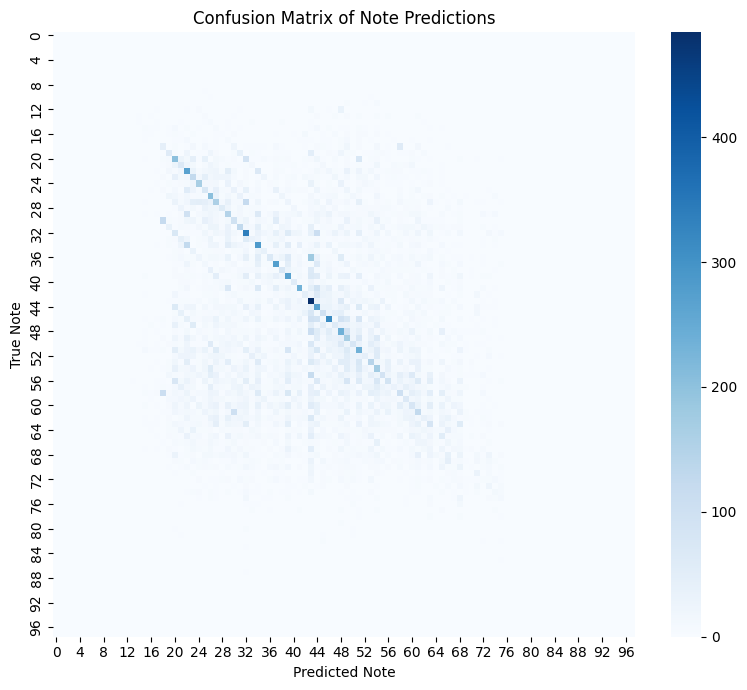

Epoch 2, Training Loss: 3.1735687987350594, Accuracy: 0.17145432398959715, Perplexity: 23.892600266923058, Precision: 0.16580035327391907, Recall: 0.17145432398959715, F1: 0.1668268312032252
Epoch 2, Validation Loss: 3.125233490985981, Accuracy: 0.18186484174508127, Perplexity: 22.76520994433367, Precision: 0.17284068405004183, Recall: 0.18186484174508127, F1: 0.1728735614195323


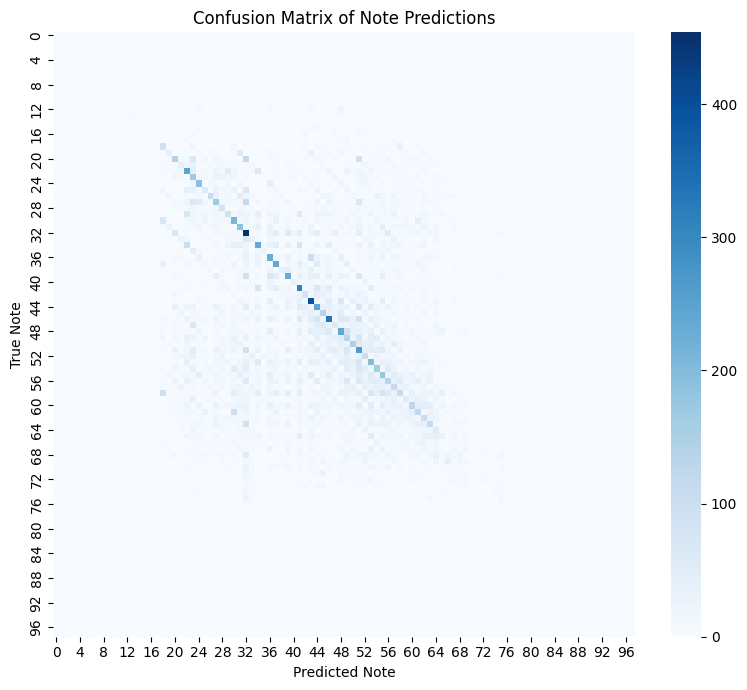

Epoch 3, Training Loss: 3.0873221217332114, Accuracy: 0.18397545268477747, Perplexity: 21.918304765158325, Precision: 0.17851228254885723, Recall: 0.18397545268477747, F1: 0.17955902053179068
Epoch 3, Validation Loss: 3.0413900361147923, Accuracy: 0.203397287058536, Perplexity: 20.934322484098963, Precision: 0.19761888962070676, Recall: 0.203397287058536, F1: 0.19496788952055732
Epoch 4, Training Loss: 3.003104879006293, Accuracy: 0.2041625090389381, Perplexity: 20.14799700042419, Precision: 0.19988742576404187, Recall: 0.2041625090389381, F1: 0.20063881662513428
Epoch 4, Validation Loss: 2.9024551378548704, Accuracy: 0.2369546621043627, Perplexity: 18.21882022073823, Precision: 0.23217018303812176, Recall: 0.2369546621043627, F1: 0.23080410574563592
Epoch 5, Training Loss: 2.9238779147648715, Accuracy: 0.2257867139813216, Perplexity: 18.61332858654053, Precision: 0.2223598768725997, Recall: 0.2257867139813216, F1: 0.22296135494639446
Epoch 5, Validation Loss: 2.8494702405019363, Accur

In [ ]:
history = train_model(model, train_loader, val_loader)

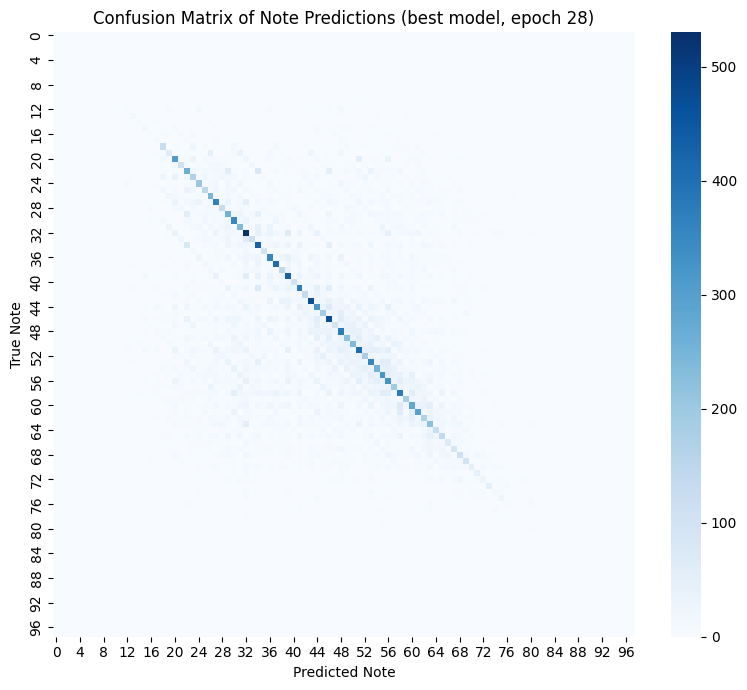

In [ ]:
# Reload the best checkpoint; everything below (confusion matrix, comparison, generation) uses it
model.load_state_dict(torch.load(WEIGHTS_DIR / "transformer_best.pt", map_location=device))
best_idx = int(np.argmin(history["val_loss"]))
best_eval = run_epoch(model, val_loader)
fig = plot_confusion_matrix(best_eval["targets"], best_eval["preds"],
                            f"Confusion Matrix of Note Predictions (best model, epoch {best_idx + 1})")
fig.savefig(FIG_DIR / "confusion_matrix_3.png", dpi=150)
plt.show()

## 6. Reproduce the training figures

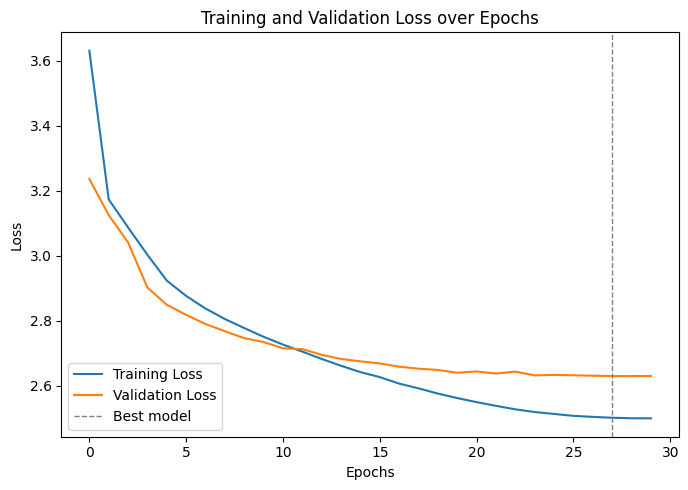

In [ ]:
epochs_axis = range(len(history["train_loss"]))

# train_val_loss_per_epoch.png
plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, history["train_loss"], label="Training Loss")
plt.plot(epochs_axis, history["val_loss"], label="Validation Loss")
plt.axvline(best_idx, color="grey", linestyle="--", linewidth=1, label="Best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "train_val_loss_per_epoch.png", dpi=150)
plt.show()

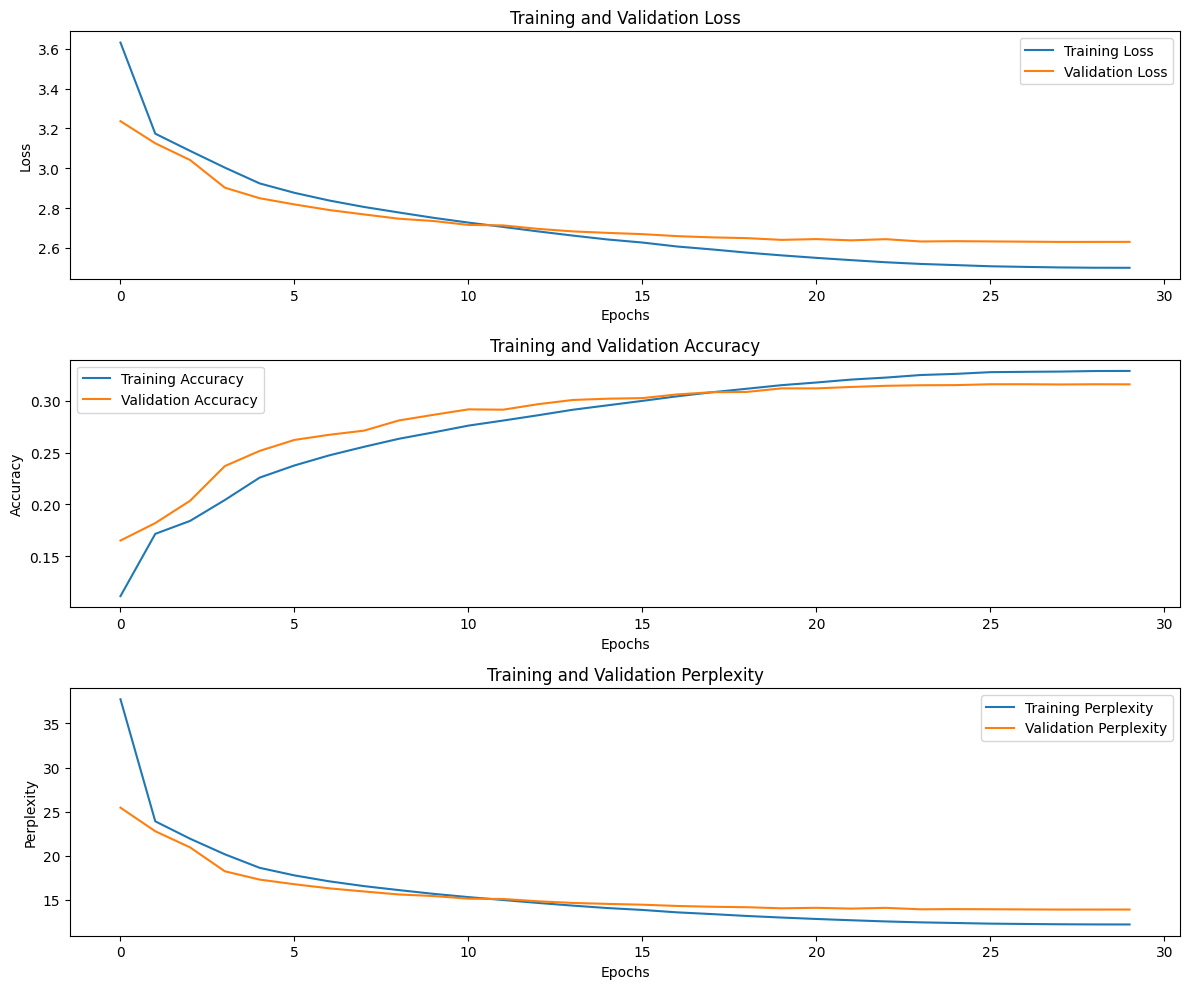

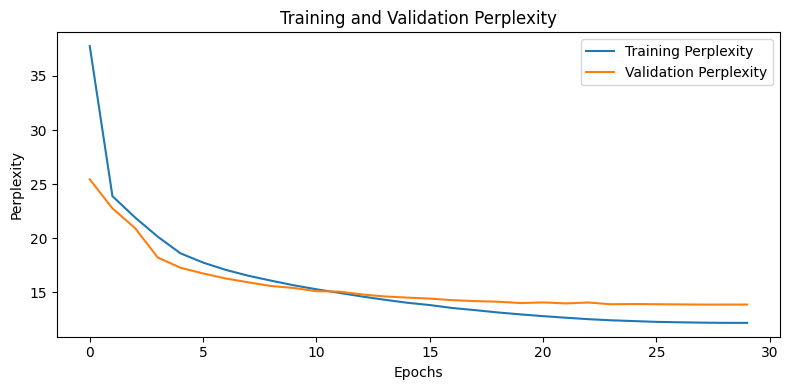

In [ ]:
# loss_accuracy_perplexity.png — the three-panel chart from the original
panels = [("loss", "Loss"), ("accuracy", "Accuracy"), ("perplexity", "Perplexity")]
plt.figure(figsize=(12, 10))
for i, (key, label) in enumerate(panels, start=1):
    plt.subplot(3, 1, i)
    plt.plot(epochs_axis, history[f"train_{key}"], label=f"Training {label}")
    plt.plot(epochs_axis, history[f"val_{key}"], label=f"Validation {label}")
    plt.xlabel("Epochs")
    plt.ylabel(label)
    plt.title(f"Training and Validation {label}")
    plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "loss_accuracy_perplexity.png", dpi=150)
plt.show()

# perplexity_plot.png
plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, history["train_perplexity"], label="Training Perplexity")
plt.plot(epochs_axis, history["val_perplexity"], label="Validation Perplexity")
plt.xlabel("Epochs")
plt.ylabel("Perplexity")
plt.title("Training and Validation Perplexity")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "perplexity_plot.png", dpi=150)
plt.show()

## 7. Compare with the original and the faithful reproduction

Training accuracy is measured on transposed windows, which are harder than the real songs. So a small train/validation gap here does not mean the model is underfitting.

In [ ]:
# Original report: validation metrics at epoch 15 (results/figures/transformer/loss_accuracy_perplexity_2.png)
original = {"loss": 5.1774, "accuracy": 0.1539, "perplexity": 177.2142,
            "precision": 0.1554, "recall": 0.1539, "f1": 0.1502}
# Faithful reproduction (first 50 notes per file, no augmentation): best epoch 6 of 15,
# from results/transformer_reproduced_metrics.json of that run
reproduction = {"loss": 3.5482, "accuracy": 0.1221, "perplexity": 34.7493,
                "precision": 0.1150, "recall": 0.1221, "f1": 0.0994}

comparison = pd.DataFrame({
    "Original report": original,
    "Faithful reproduction (best)": reproduction,
    f"This notebook (best, epoch {best_idx + 1})": {m: history[f"val_{m}"][best_idx] for m in METRICS},
}).rename(index=lambda m: f"Validation {m}")
comparison.round(4)

,Original report,Faithful reproduction (best),"This notebook (best, epoch 28)"
Validation loss,5.1774,3.5482,2.6301
Validation accuracy,0.1539,0.1221,0.3158
Validation perplexity,177.2142,34.7493,13.8757
Validation precision,0.1554,0.1150,0.3131
Validation recall,0.1539,0.1221,0.3158
Validation f1,0.1502,0.0994,0.3128


**Comparability.** The validation set here is every non-overlapping 50-note window of the held-out songs. The earlier runs used only the first 50 notes of each song, and the tokens now come in playing order with drums removed. The numbers measure the same task on better-prepared data, so they are not an exact like-for-like comparison. Report them as an improved setup next to the reproduction.

## 8. Generate music

Each piece starts from the real 16-note opening of a validation song, which the model never trained on. It then generates 100 more notes, sampling from the 10 most likely notes at temperature 0.9. Only the last 50 tokens are passed as context, because that is the model's window. The padding token is never sampled.

In [ ]:
@torch.no_grad()
def generate_sequence(model, prompt_ids, n_new=GEN_LEN, temperature=TEMPERATURE, top_k=TOP_K):
    model.eval()
    ids = list(prompt_ids)
    for _ in range(n_new):
        context = torch.tensor([ids[-SEQ_LEN:]], device=device)
        logits = model(input_ids=context).logits[0, -1] / temperature
        logits[PAD_ID] = float("-inf")
        if top_k:
            kth_best = torch.topk(logits, top_k).values[-1]
            logits[logits < kth_best] = float("-inf")
        ids.append(torch.multinomial(F.softmax(logits, dim=-1), 1).item())
    return ids


def ids_to_midi(ids, path, ticks_per_beat=480, note_ticks=240, velocity=80, bpm=120):
    mid = mido.MidiFile(ticks_per_beat=ticks_per_beat)
    track = mido.MidiTrack()
    mid.tracks.append(track)
    track.append(mido.MetaMessage("set_tempo", tempo=mido.bpm2tempo(bpm), time=0))
    track.append(mido.Message("program_change", program=0, time=0))   # acoustic grand piano
    for i in ids:
        pitch = id_to_pitch[i]
        track.append(mido.Message("note_on", note=pitch, velocity=velocity, time=0))
        track.append(mido.Message("note_off", note=pitch, velocity=0, time=note_ticks))
    mid.save(path)


torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
prompt_songs = [s for s in val_songs if len(s) >= PROMPT_LEN]
prompts = [[pitch_to_id[p] for p in prompt_songs[rng.integers(len(prompt_songs))][:PROMPT_LEN]]
           for _ in range(N_GEN_SAMPLES)]
generated_full = [generate_sequence(model, p) for p in prompts]
generated = [g[PROMPT_LEN:] for g in generated_full]      # the model's own notes, without the prompt

midi_path = AUDIO_DIR / "transformer_generated.mid"
ids_to_midi(generated_full[0], midi_path)
print(f"Wrote {midi_path.relative_to(REPO_ROOT)} (16-note prompt + {GEN_LEN} generated notes)")
print("Prompt:   ", [id_to_pitch[i] for i in generated_full[0][:PROMPT_LEN]])
print("Generated:", [id_to_pitch[i] for i in generated[0][:20]], "...")

Wrote results/audio/transformer_generated.mid (16-note prompt + 100 generated notes)
Prompt:    [57, 62, 50, 57, 62, 45, 57, 62, 57, 62, 48, 57, 62, 57, 62, 50]
Generated: [57, 62, 50, 57, 62, 50, 58, 62, 50, 57, 62, 50, 57, 62, 50, 57, 62, 50, 57, 62] ...


## 9. Novelty, diversity and FAD proxy

The functions below match the GAN notebook's definitions exactly (see the screenshots in `results/figures/gan/`).

- **Novelty:** the mean Euclidean distance from each generated sequence to the real sequences. RESULTS.md describes it as the distance to the *nearest* real sequence, so both versions are reported.
- **Diversity:** the mean pairwise Euclidean distance between generated sequences.
- **FAD proxy:** MSE between the per-position means of generated and real sequences, plus MSE between their variances.

Scores use the first 50 *generated* notes (the prompt is excluded). They are compared against non-overlapping 50-note windows of the training songs, as raw MIDI pitch and as pitch normalised to [0, 1]. The normalised numbers from the faithful reproduction are shown alongside for comparison.

In [ ]:
def novelty_metric(generated_sequences, real_sequences):
    distances = []
    for gen_seq in generated_sequences:
        gen_seq_flat = gen_seq.flatten()
        real_distances = [euclidean(gen_seq_flat, real_seq.flatten()) for real_seq in real_sequences]
        distances.append(np.mean(real_distances))
    return np.mean(distances)


def nearest_neighbour_novelty(generated_sequences, real_sequences):
    return np.mean([min(euclidean(g.flatten(), r.flatten()) for r in real_sequences)
                    for g in generated_sequences])


def diversity_metric(sequences):
    n = len(sequences)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(euclidean(sequences[i].flatten(), sequences[j].flatten()))
    return np.mean(distances)


def fad_metric(generated_sequences, real_sequences):
    gen_means = np.mean(generated_sequences, axis=0)
    gen_vars = np.var(generated_sequences, axis=0)
    real_means = np.mean(real_sequences, axis=0)
    real_vars = np.var(real_sequences, axis=0)
    mean_diff = mean_squared_error(gen_means.flatten(), real_means.flatten())
    var_diff = mean_squared_error(gen_vars.flatten(), real_vars.flatten())
    return mean_diff + var_diff


to_pitch = np.vectorize(id_to_pitch.get)
gen_pitch = to_pitch(np.array([g[:SEQ_LEN] for g in generated])).astype(float)
real_pitch = np.array([s[start:start + SEQ_LEN] for s in train_songs
                       for start in range(0, len(s) - SEQ_LEN + 1, SEQ_LEN)], dtype=float)

p_lo, p_hi = min(min(s) for s in note_sequences), max(max(s) for s in note_sequences)
representations = {"raw MIDI pitch": (gen_pitch, real_pitch),
                   "normalised pitch [0, 1]": ((gen_pitch - p_lo) / (p_hi - p_lo), (real_pitch - p_lo) / (p_hi - p_lo))}

gen_metrics = {}
for name, (gen, real) in representations.items():
    gen_metrics[name] = {
        "novelty (mean distance, as in original code)": novelty_metric(gen, real),
        "novelty (nearest neighbour, as in RESULTS.md)": nearest_neighbour_novelty(gen, real),
        "diversity": diversity_metric(gen),
        "FAD proxy": fad_metric(gen, real),
    }
# Faithful reproduction, normalised pitch (results/transformer_reproduced_metrics.json of that run)
gen_metrics["faithful reproduction, normalised"] = {
    "novelty (mean distance, as in original code)": 1.4284,
    "novelty (nearest neighbour, as in RESULTS.md)": 0.8591,
    "diversity": 1.3787,
    "FAD proxy": 0.0030,
}
print(f"{len(gen_pitch)} generated vs {len(real_pitch):,} real sequences of {SEQ_LEN} notes")
pd.DataFrame(gen_metrics).round(4)

20 generated vs 3,692 real sequences of 50 notes


,raw MIDI pitch,"normalised pitch [0, 1]","faithful reproduction, normalised"
"novelty (mean distance, as in original code)",136.2376,1.5842,1.4284
"novelty (nearest neighbour, as in RESULTS.md)",62.5562,0.7274,0.8591
diversity,136.0658,1.5822,1.3787
FAD proxy,1604.8797,0.0011,0.0030


The faithful reproduction generated too many high notes (MIDI 72–84) and almost no bass. This chart checks whether the generated pitch distribution now matches the training data.

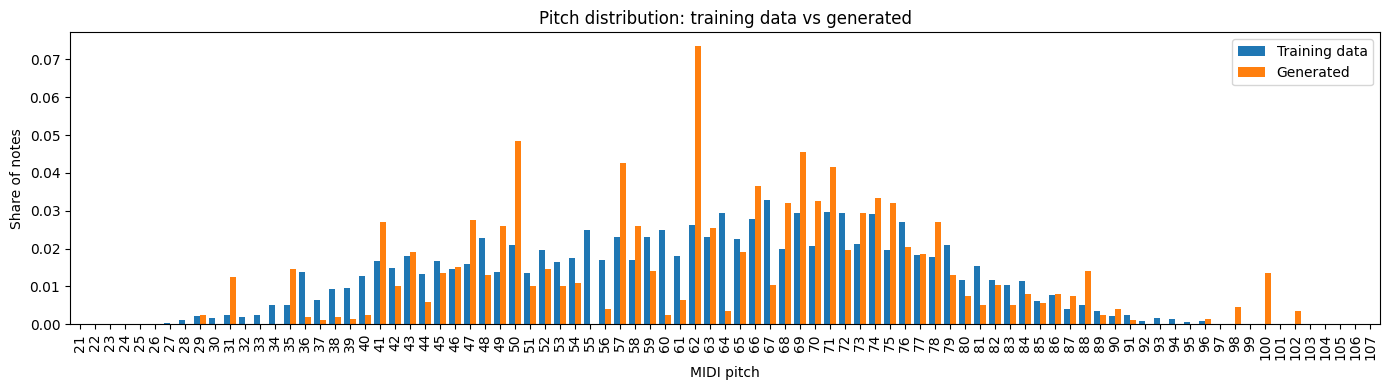

Distinct pitches: training 87, generated 62
Top-5 pitches' share of generated notes: 25.1% (training data: 15.1%)


In [ ]:
real_counts = pd.Series(np.concatenate([np.asarray(s) for s in train_songs])).value_counts(normalize=True)
gen_counts = pd.Series(np.concatenate([to_pitch(np.array(g)) for g in generated])).value_counts(normalize=True)
dist = pd.DataFrame({"Training data": real_counts, "Generated": gen_counts}).fillna(0).sort_index()

ax = dist.plot(kind="bar", figsize=(14, 4), width=0.8)
ax.set_xlabel("MIDI pitch")
ax.set_ylabel("Share of notes")
ax.set_title("Pitch distribution: training data vs generated")
plt.tight_layout()
plt.savefig(FIG_DIR / "pitch_distribution.png", dpi=150)
plt.show()

print(f"Distinct pitches: training {int((dist['Training data'] > 0).sum())}, generated {int((dist['Generated'] > 0).sum())}")
print(f"Top-5 pitches' share of generated notes: {gen_counts.head(5).sum():.1%} "
      f"(training data: {real_counts.head(5).sum():.1%})")

## 10. Save metrics

In [ ]:
summary = {
    "config": {"seq_len": SEQ_LEN, "train_stride": TRAIN_STRIDE, "transpose_shifts": TRANSPOSE_SHIFTS,
               "skip_drums": SKIP_DRUMS, "max_epochs": MAX_EPOCHS, "patience": PATIENCE,
               "epochs_run": len(history["val_loss"]), "batch_size": BATCH_SIZE, "lr": LR,
               "weight_decay": WEIGHT_DECAY, "dropout": DROPOUT, "n_embd": N_EMBD, "n_layer": N_LAYER,
               "n_head": N_HEAD, "vocab_size": VOCAB_SIZE, "prompt_len": PROMPT_LEN, "temperature": TEMPERATURE,
               "top_k": TOP_K, "n_generated": N_GEN_SAMPLES, "seed": SEED,
               "train_windows": len(train_ds), "val_windows": len(val_ds)},
    "best_epoch": best_idx + 1,
    "best_epoch_validation": {m: float(history[f"val_{m}"][best_idx]) for m in METRICS},
    "generation_metrics": {rep: {k: float(v) for k, v in vals.items()} for rep, vals in gen_metrics.items()},
    "history": {k: [float(x) for x in v] for k, v in history.items()},
}
out = REPO_ROOT / "results" / "transformer_reproduced_metrics.json"
out.write_text(json.dumps(summary, indent=2))
print(f"Saved {out.relative_to(REPO_ROOT)}")

Saved results/transformer_reproduced_metrics.json


In [ ]:
# On Colab, download everything this notebook produced (figures, MIDI, metrics) as one zip.
# Unzip it into the repo's results/ folder to keep the outputs.
if IN_COLAB:
    import shutil
    from google.colab import files
    archive = shutil.make_archive("/content/transformer_results", "zip", REPO_ROOT / "results")
    files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes on reading the results

- **Where the gains come from.** Most of the improvement should come from using every note of each song and from transposition. Together they give the model hundreds of times more distinct training examples than the first-50-notes setup. Dropout, weight decay and the LR schedule mainly delay overfitting.
- **Accuracy is a weak measure of music quality.** Next-note accuracy rewards predicting the most common continuation. Use validation loss / perplexity to compare runs, and listen to `results/audio/transformer_generated.mid` to judge the music.
- **A likely bug in the original training metrics.** In the original logs, training accuracy (0.07) was lower than validation accuracy (0.15) even though training loss was far lower (0.38 vs 5.18). This notebook compares each prediction with the *next* note in both splits.
- **Next steps if you want more.** You could try a longer context (`SEQ_LEN = 128`, though novelty/diversity/FAD are then no longer comparable) or a larger model once validation loss stops improving. The biggest remaining step is to pretrain on a large MIDI corpus such as Lakh MIDI or MAESTRO, then fine-tune on these Pokémon songs.